In [1]:
import torch
import numpy as np

In [2]:
#Tensor Initialization
data = [[1,2],[3,4]]
x_data = torch.tensor(data)
x_data

tensor([[1, 2],
        [3, 4]])

In [3]:
#Tensor Initialization from numpy
np_array = np.array(data)
x_data = torch.from_numpy(np_array)
x_data

tensor([[1, 2],
        [3, 4]])

In [4]:
x_ones = torch.ones_like(x_data) # retains the properties of x_data
x_ones


tensor([[1, 1],
        [1, 1]])

In [5]:
x_random = torch.rand_like(x_data, dtype=torch.float) # random tensor with the same shape as x_data
x_random

tensor([[0.9319, 0.3762],
        [0.6449, 0.4587]])

In [6]:
print(f"Shape of tensor: {x_random.shape}")
print(f"Datatype of tensor: {x_random.dtype}")
print(f"Device tensor is stored on: {x_random.device}")

Shape of tensor: torch.Size([2, 2])
Datatype of tensor: torch.float32
Device tensor is stored on: cpu


In [7]:
if torch.backends.mps.is_available():
    x_random = x_random.to('mps') # Move tensor to MPS
    print("MPS is available. Moving tensor to GPU.")

MPS is available. Moving tensor to GPU.


In [8]:
tensor = torch.rand(4,4)
tensor

tensor([[0.4670, 0.0149, 0.0376, 0.3421],
        [0.5907, 0.2484, 0.0501, 0.8309],
        [0.5205, 0.1086, 0.2549, 0.2424],
        [0.9694, 0.0560, 0.5093, 0.6731]])

In [9]:
#Modify column 1
tensor[:,1] = 0
tensor

tensor([[0.4670, 0.0000, 0.0376, 0.3421],
        [0.5907, 0.0000, 0.0501, 0.8309],
        [0.5205, 0.0000, 0.2549, 0.2424],
        [0.9694, 0.0000, 0.5093, 0.6731]])

In [10]:
#Concat tensors
tensor_concat = torch.cat((tensor, tensor), dim=1)
tensor_concat

tensor([[0.4670, 0.0000, 0.0376, 0.3421, 0.4670, 0.0000, 0.0376, 0.3421],
        [0.5907, 0.0000, 0.0501, 0.8309, 0.5907, 0.0000, 0.0501, 0.8309],
        [0.5205, 0.0000, 0.2549, 0.2424, 0.5205, 0.0000, 0.2549, 0.2424],
        [0.9694, 0.0000, 0.5093, 0.6731, 0.9694, 0.0000, 0.5093, 0.6731]])

In [11]:
tensor = torch.tensor([[1,2],[3,4]])
tensor


tensor([[1, 2],
        [3, 4]])

In [12]:
tensor = tensor.mul(tensor) # Element-wise multiplication
tensor

tensor([[ 1,  4],
        [ 9, 16]])

In [13]:
tensor.add_(torch.tensor([[5,5],[5,5]])) # In-place addition
tensor

tensor([[ 6,  9],
        [14, 21]])

In [14]:
#Producto punto
tensor_a = torch.tensor([[1,2],[3,4]])
tensor_b = torch.tensor([[5,6],[7,8]])
result = tensor_a @ tensor_b
result

tensor([[19, 22],
        [43, 50]])

In [15]:
tensor_a = torch.tensor([2, 2])
tensor_b = torch.tensor([3, 4])
result = tensor_a @ tensor_b
result

tensor(14)

In [16]:
#Autoguards
from torchvision.models import resnet18, ResNet18_Weights

model = resnet18(weights=ResNet18_Weights.DEFAULT)
data = torch.rand(1,3,64,64)
labels = torch.rand(1,1000)

In [17]:
predictions = model(data) # Forward pass
predictions

tensor([[-5.3682e-01, -4.7870e-01, -8.3973e-01, -1.4708e+00, -8.7500e-01,
         -2.4276e-01, -6.4254e-01,  4.7574e-01,  4.6466e-01, -8.1832e-01,
         -9.6202e-01, -1.1570e+00, -4.4808e-01, -1.0364e+00, -8.6585e-01,
         -4.2235e-01, -7.9358e-01, -2.3101e-01, -8.1370e-01, -7.5214e-01,
         -1.6570e+00, -4.1176e-01, -1.5589e+00,  2.1561e-01, -7.3729e-01,
         -1.1790e+00, -5.1792e-01, -1.2202e+00, -9.8171e-01, -2.8164e-01,
         -4.6611e-01, -5.7781e-01, -1.5440e-01, -4.9827e-01,  1.4793e-02,
         -1.0731e-01,  8.1505e-01, -5.7722e-01,  4.0499e-02,  1.4554e-01,
         -4.3050e-01, -6.2185e-01, -7.0015e-01,  2.1891e-02, -6.0947e-01,
         -3.3910e-01, -5.5730e-01, -1.5038e-01, -1.0893e+00, -1.0799e+00,
         -4.8890e-01,  5.8007e-01, -9.3154e-02, -5.1609e-01, -4.5507e-02,
         -1.1315e+00, -2.9115e-01, -1.3899e+00, -3.6691e-01, -4.5219e-01,
          8.7926e-01,  2.8067e-01,  6.0623e-02,  4.1102e-01, -6.4189e-01,
         -3.8335e-01, -2.1498e-01, -5.

In [18]:
loss = (predictions - labels).sum() # Dummy loss
loss.backward() # Backpropagation

In [19]:
optimizer = torch.optim.SGD(model.parameters(), lr=1e-2)
optimizer.step() # Update the weights with gradient descent

In [20]:
## Like autograd works

a = torch.tensor([2., 3.], requires_grad=True)
b = torch.tensor([6., 4.], requires_grad=True)

In [21]:
Q = 3*a**3 - b**2
Q

tensor([-12.,  65.], grad_fn=<SubBackward0>)

In [22]:
external_grad = torch.tensor([1., 1.])
Q.backward(gradient=external_grad)

In [23]:
# Check if gradients are corrects
print(9*a**2 == a.grad)
print(-2*b == b.grad)

tensor([True, True])
tensor([True, True])


In [24]:
#Red para procesar imagenes
import torch.nn as nn
import torch.nn.functional as F

class Net(torch.nn.Module):

    def __init__(self):
        super(Net, self).__init__()
        # 1 input image channel, 6 output channels, 5x5 square convolution kernel
        self.conv1 = nn.Conv2d(1, 6, 5)
        self.conv2 = nn.Conv2d(6, 16, 5)
        # an affine operation: y = Wx + b
        self.fc1 = nn.Linear(16 * 5 * 5, 120)
        self.fc2 = nn.Linear(120, 84)
        self.fc3 = nn.Linear(84, 10)

    def forward(self, input):
        c1 = F.relu(self.conv1(input)) # IN 32
        print("C1 shape: ", c1.shape)
        s1 = F.max_pool2d(c1, (2, 2)) # OUT 14 (conv / pool size)
        print("S1 shape: ", s1.shape)
        c2 = F.relu(self.conv2(s1)) # IN 14
        print("C2 shape: ", c2.shape)
        s2 = F.max_pool2d(c2, 2) # OUT 5
        print("S2 shape before flatten: ", s2.shape)
        s2 = torch.flatten(s2, 1) # flatten all dimensions except batch
        print("S2 shape after flatten: ", s2.shape)
        c3 = F.relu(self.fc1(s2))
        c4 = F.relu(self.fc2(c3))
        output = self.fc3(c4)
        return output


In [25]:
net = Net()
net

Net(
  (conv1): Conv2d(1, 6, kernel_size=(5, 5), stride=(1, 1))
  (conv2): Conv2d(6, 16, kernel_size=(5, 5), stride=(1, 1))
  (fc1): Linear(in_features=400, out_features=120, bias=True)
  (fc2): Linear(in_features=120, out_features=84, bias=True)
  (fc3): Linear(in_features=84, out_features=10, bias=True)
)

In [26]:
params = list(net.parameters())
params

[Parameter containing:
 tensor([[[[-0.1858, -0.1483, -0.1143,  0.1427, -0.0294],
           [-0.0689, -0.0965,  0.1999, -0.1381, -0.1029],
           [ 0.0741,  0.1789,  0.0054,  0.1167,  0.1704],
           [-0.1414,  0.0216, -0.0768, -0.0163, -0.0014],
           [-0.0383, -0.0302, -0.1648, -0.1663,  0.1950]]],
 
 
         [[[ 0.0136,  0.0537, -0.0469,  0.0249,  0.0477],
           [-0.0305,  0.0565, -0.0735,  0.0639, -0.1703],
           [ 0.1524,  0.0502, -0.0840,  0.0300, -0.0883],
           [-0.0759,  0.1909,  0.1097, -0.0263,  0.1564],
           [ 0.1836,  0.0619, -0.0504,  0.0806, -0.0009]]],
 
 
         [[[ 0.1152, -0.0865,  0.0628, -0.0442, -0.1550],
           [ 0.0607,  0.0102,  0.0108, -0.0139,  0.1560],
           [ 0.0892,  0.0846,  0.0683, -0.1071, -0.0340],
           [-0.0573,  0.1461,  0.0123,  0.0700,  0.0312],
           [-0.1069,  0.0422,  0.1887, -0.0216,  0.0258]]],
 
 
         [[[ 0.1539,  0.0864, -0.1903, -0.0375,  0.0403],
           [ 0.1683, -0.0456, -

In [27]:
print("Number of parameters:", len(params))
print("Shape of first parameter:", params[0].shape)

Number of parameters: 10
Shape of first parameter: torch.Size([6, 1, 5, 5])


In [28]:
input = torch.rand(1, 1, 32, 32) # Batch size of 1, 1 input channel, 32x32 image
output = net(input)
output

C1 shape:  torch.Size([1, 6, 28, 28])
S1 shape:  torch.Size([1, 6, 14, 14])
C2 shape:  torch.Size([1, 16, 10, 10])
S2 shape before flatten:  torch.Size([1, 16, 5, 5])
S2 shape after flatten:  torch.Size([1, 400])


tensor([[ 0.0463,  0.0041,  0.0460, -0.0118, -0.0487,  0.1150, -0.0263, -0.0309,
         -0.0117, -0.0941]], grad_fn=<AddmmBackward0>)

In [29]:
net.zero_grad() # Zero the gradient buffers of all parameters and backprops with random gradients
output.backward(torch.rand(1, 10)) # Backpropagation with random gradients

In [30]:
# Loss function and optimizer
output = net(input) # Forward pass to get the output
target = torch.rand(10) # Dummy target
criterion = nn.MSELoss() # Mean Squared Error Loss

loss = criterion(output, target)
print("Target ", target)
print("Loss:", loss)

C1 shape:  torch.Size([1, 6, 28, 28])
S1 shape:  torch.Size([1, 6, 14, 14])
C2 shape:  torch.Size([1, 16, 10, 10])
S2 shape before flatten:  torch.Size([1, 16, 5, 5])
S2 shape after flatten:  torch.Size([1, 400])
Target  tensor([0.1634, 0.5818, 0.2652, 0.8035, 0.6928, 0.7295, 0.8978, 0.0874, 0.3063,
        0.7070])
Loss: tensor(0.3598, grad_fn=<MseLossBackward0>)


/Users/damaso/.pyenv/versions/3.13.5/lib/python3.13/site-packages/torch/nn/modules/loss.py:610: UserWarning: Using a target size (torch.Size([10])) that is different to the input size (torch.Size([1, 10])). This will likely lead to incorrect results due to broadcasting. Please ensure they have the same size.
  return F.mse_loss(input, target, reduction=self.reduction)


In [31]:
print("Loss grad_fn:", loss.grad_fn)
print("Loss grad_fn next functions:", loss.grad_fn.next_functions)
print("Loss grad_fn next functions next functions:", loss.grad_fn.next_functions[0][0])
print("Loss grad_fn next functions next functions next functions:", loss.grad_fn.next_functions[0][0].next_functions[0][0])

Loss grad_fn: <MseLossBackward0 object at 0x12cc9d420>
Loss grad_fn next functions: ((<AddmmBackward0 object at 0x12cc9e020>, 0), (None, 0))
Loss grad_fn next functions next functions: <AddmmBackward0 object at 0x12cc9d420>
Loss grad_fn next functions next functions next functions: <AccumulateGrad object at 0x12cc9d420>


In [32]:
net.zero_grad() # Zero the gradient buffers
print('conv1.bias.grad before backward: ', net.conv1.bias.grad)
loss.backward() # Backpropagation
print('conv1.bias.grad after backward: ', net.conv1.bias.grad)

conv1.bias.grad before backward:  None
conv1.bias.grad after backward:  tensor([-0.0051, -0.0110,  0.0017,  0.0002, -0.0082,  0.0025])


In [33]:
# Weights update
import torch.optim as optim

optimizer = optim.SGD(net.parameters(), lr=0.01) # Stochastic Gradient Descent
optimizer.zero_grad()
output = net(input) # Forward pass to get the output
loss = criterion(output, target) # Compute the loss
loss.backward() # Backpropagation
optimizer.step() # Update the weights with gradient descent

C1 shape:  torch.Size([1, 6, 28, 28])
S1 shape:  torch.Size([1, 6, 14, 14])
C2 shape:  torch.Size([1, 16, 10, 10])
S2 shape before flatten:  torch.Size([1, 16, 5, 5])
S2 shape after flatten:  torch.Size([1, 400])


In [34]:
# Training a image classifier
import torch
import torchvision
import torchvision.transforms as transforms
from torchvision.transforms import Compose

In [35]:
transform = Compose(
    [transforms.ToTensor(),
     transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))])
batch_size = 4

train_set = torchvision.datasets.CIFAR10(root='./data', train=True, download=True, transform=transform)
train_loader = torch.utils.data.DataLoader(train_set, batch_size=batch_size, shuffle=True, num_workers=2)

test_set = torchvision.datasets.CIFAR10(root='./data', train=False, download=True, transform=transform)
test_loader = torch.utils.data.DataLoader(test_set, batch_size=batch_size, shuffle=False, num_workers=2)

classes = ('plane', 'car', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck')

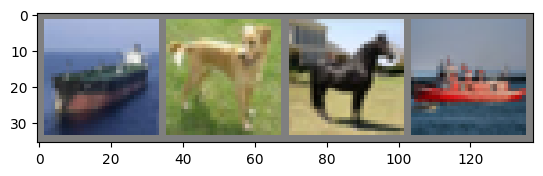

ship  dog   horse ship 


In [36]:
import matplotlib.pyplot as plt
import numpy as np

def img_show(img):
    img = img / 2 + 0.5 # unnormalize
    npimg = img.numpy()
    plt.imshow(np.transpose(npimg, (1, 2, 0)))
    plt.show()

# get some random training images
dataiter = iter(train_loader)
images, labels = next(dataiter)

# show images
img_show(torchvision.utils.make_grid(images))
# print labels
print(' '.join(f'{classes[labels[j]]:5s}' for j in range(batch_size)))

In [37]:
class ImageNet(nn.Module):

    def __init__(self):
        super().__init__()
        self.conv1 = nn.Conv2d(3, 6, 5)
        self.pool = nn.MaxPool2d(2, 2)
        self.conv2 = nn.Conv2d(6, 16, 5)

        # Net fully connected layers
        self.fc1 = nn.Linear(16 * 5 * 5, 120)
        self.fc2 = nn.Linear(120, 84)
        self.fc3 = nn.Linear(84, 10)

    def forward(self, x):
        x = self.pool(F.relu(self.conv1(x)))
        x = self.pool(F.relu(self.conv2(x)))
        x = torch.flatten(x, 1) # flatten all dimensions holding the batch dimension
        x = F.relu(self.fc1(x))
        x = F.relu(self.fc2(x))
        output = self.fc3(x)
        return output

In [55]:
# Training on GPU
device = torch.device("mps" if torch.backends.mps.is_available() else "cpu")
device

device(type='mps')

In [64]:
net = ImageNet()
#net.to(device)
#inputs, labels = train_loader.to(device), data[1].to(device)

In [65]:
# Loss function and optimizer
criterion = nn.CrossEntropyLoss()
optimizer = optim.SGD(net.parameters(), lr=0.001, momentum=0.9)

In [66]:
for epoch in range(2): # loop over the dataset multiple times

    runnin_loss = 0.0
    for i, data in enumerate(train_loader, 0):
        # get the inputs; data is a list of [inputs, labels] whitout GPU
        input, labels = data
        # WHIT GPU
        #inputs, labels = data[i].to(device), data[i].to(device)

        optimizer.zero_grad() # zero the parameter gradients

        output = net(input) # Forward pass to get the output
        loss = criterion(output, labels) # Compute the loss
        loss.backward() # Backpropagation
        optimizer.step() # Update the weights with gradient descent

        # print statistics
        runnin_loss += loss.item()
        if i % 2000 == 1999:    # print every 2000 mini-batches
            print(f'[{epoch + 1}, {i + 1:5d}] loss: {runnin_loss / 2000:.3f}')
            runnin_loss = 0.0
print('Finished Training')

[1,  2000] loss: 2.146
[1,  4000] loss: 1.806
[1,  6000] loss: 1.660
[1,  8000] loss: 1.565
[1, 10000] loss: 1.494
[1, 12000] loss: 1.458
[2,  2000] loss: 1.380
[2,  4000] loss: 1.380
[2,  6000] loss: 1.328
[2,  8000] loss: 1.300
[2, 10000] loss: 1.286
[2, 12000] loss: 1.274
Finished Training


In [67]:
# Save the trained model
PATH = './models/cifar_net.pth'
torch.save(net.state_dict(), PATH)

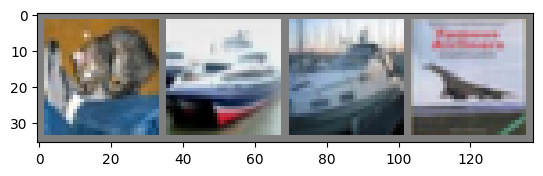

GroundTruth:  cat   ship  ship  plane


In [68]:
dataiter = iter(test_loader)
images, labels = next(dataiter)

img_show(torchvision.utils.make_grid(images))
print('GroundTruth: ', ' '.join(f'{classes[labels[j]]:5s}' for j in range(batch_size)))

In [43]:
net = ImageNet()
net.load_state_dict(torch.load(PATH, weights_only=True))

<All keys matched successfully>

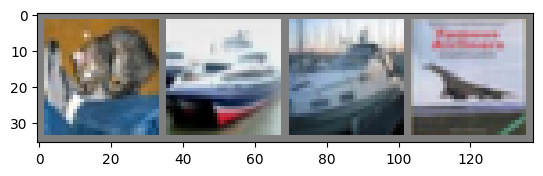

Predicted:  bird  ship  ship  ship 


In [44]:
outputs = net(images)
_, predict = torch.max(outputs, 1)
img_show(torchvision.utils.make_grid(images))
print('Predicted: ', ' '.join(f'{classes[predict[j]]:5s}' for j in range(batch_size)))

In [45]:
# NetWork performance on the whole test dataset
correct = 0
total = 0

with torch.no_grad():
    for data in test_loader:
        images, labels = data
        # calculate outputs by running images through the network
        outputs = net(images)
        # the class with the highest energy is what we choose as prediction
        _, predicted = torch.max(outputs, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

print(f'Accuracy of the network on the 10000 test images: {100 * correct / total} %')

Accuracy of the network on the 10000 test images: 55.42 %


In [46]:
# Accuracy from each class
correct_pred = {classname: 0 for classname in classes}
total_pred = {classname: 0 for classname in classes}

with torch.no_grad():
    for data in test_loader:
        images, labels = data
        outputs = net(images)
        _, predicted = torch.max(outputs, 1)
        # collect the correct predictions for each class
        for label, prediction in zip(labels, predicted):
            if label == prediction:
                correct_pred[classes[label]] += 1
            total_pred[classes[label]] += 1

for classname, correct_count in correct_pred.items():
    accuracy = 100 * float(correct_count) / total_pred[classname]
    print(f'Accuracy for class: {classname:5s} is {accuracy:.1f} %')

Accuracy for class: plane is 43.8 %
Accuracy for class: car   is 73.4 %
Accuracy for class: bird  is 49.0 %
Accuracy for class: cat   is 23.8 %
Accuracy for class: deer  is 50.5 %
Accuracy for class: dog   is 42.7 %
Accuracy for class: frog  is 72.7 %
Accuracy for class: horse is 67.9 %
Accuracy for class: ship  is 74.7 %
Accuracy for class: truck is 55.7 %


In [ ]:
# Training on GPU
device = torch.device("mps" if torch.backends.mps.is_available() else "cpu")
device

device(type='mps')

In [49]:
net.to(device)
inputs, labels = data[0].to(device), data[1].to(device)